# 02. Federated Data Partitioning & Non-IID Dirichlet Distribution
This notebook inspects how training data is partitioned across 5 virtual edge clients.
To simulate realistic, heterogeneous agricultural edge environments, we apply a Dirichlet distribution ($\alpha = 0.1$).

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Add project root to path
sys.path.append(os.path.abspath('..'))

from utils.dataset import load_federated_data

# 1. Load federated partitions (5 clients, Non-IID alpha=0.1)
client_loaders, val_loader, classes = load_federated_data(
    data_dir='../data/PlantVillage',
    num_clients=5,
    batch_size=32,
    iid=False,
    alpha=0.1
)

num_clients = len(client_loaders)
num_classes = len(classes)
print(f"Loaded {num_clients} virtual clients across {num_classes} plant disease classes.")


❄️ Freezing 4128 test images to data/test_holdout for the Streamlit dashboard...
✅ Test data successfully frozen!

Dataset Mode: Non-IID (Dirichlet Distribution, alpha=0.1)
Loaded 5 virtual clients across 15 plant disease classes.


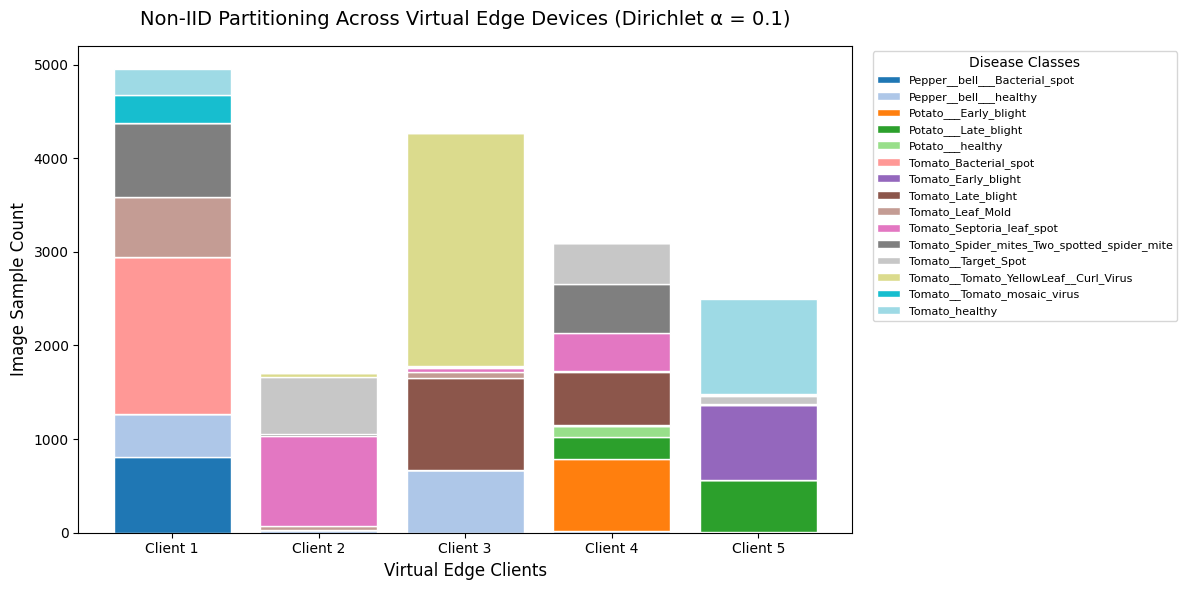

In [2]:
# 2. Count class occurrences per client
distribution = np.zeros((num_clients, num_classes))
for cid, loader in enumerate(client_loaders):
    for _, labels in loader:
        for label in labels:
            distribution[cid][label.item()] += 1

# 3. Plot stacked distribution
fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(num_clients)
client_labels = [f"Client {i+1}" for i in range(num_clients)]
colors = plt.cm.tab20(np.linspace(0, 1, num_classes))

for i in range(num_classes):
    class_counts = distribution[:, i]
    ax.bar(client_labels, class_counts, bottom=bottom, label=classes[i], color=colors[i], edgecolor='white')
    bottom += class_counts

plt.title('Non-IID Partitioning Across Virtual Edge Devices (Dirichlet α = 0.1)', fontsize=14, pad=15)
plt.xlabel('Virtual Edge Clients', fontsize=12)
plt.ylabel('Image Sample Count', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title="Disease Classes")
plt.tight_layout()
plt.show()